# Milestone 5 solution:  Model interpretability and fairness
 
## Objective
 
- The city services are unwilling to make scheduling changes based on a black
  box model. We need to make the results more interpretable. We also should ensure   
  that there is no undesired biases in the model predictions.
  
 
## Requirements
 
Install the Python package that we have created in our previous milestone, which contains some of the useful functions,

In [1]:
! pip install --upgrade https://public-sym.s3-eu-west-1.amazonaws.com/LP-safety-US-cities/safety-events-cities-1.0.0.tar.gz

  Using cached https://public-sym.s3-eu-west-1.amazonaws.com/LP-safety-US-cities/safety-events-cities-1.0.0.tar.gz (2.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done


In [2]:
# this plugin requires to run "pip install nb-black"
%load_ext nb_black

# Reload modules automatically when importing code
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd

import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

We start by list most frequent categories, for future reference,

In [4]:
from safety_events_cities.milestone3 import load_data

df = load_data(
    "../data/safety-SanFrancisco-2.parquet",
    category="Street and Sidewalk Cleaning",
    years=[2016, 2017, 2018, 2019],
    freq="6h",
)

df.head()

,dateTime,neighborhood,count
0,2016-01-01 00:00:00,Mission,2
1,2016-01-01 00:00:00,Nob Hill,1
2,2016-01-01 06:00:00,Ingleside,1
3,2016-01-01 06:00:00,Mission,9
4,2016-01-01 06:00:00,Nob Hill,5


<IPython.core.display.Javascript object>

## 1. Model interpretability

We will illustrate how to make predictions of our model mode interpretable on the example of "Street and Sidewalk Cleaning" event category.

First we need to reproduce the pipeline and pre-processing steps from Milestone 3. We similarly augment the features with weather and holiday data.

In [5]:
import pandas as pd


def add_weather(df):
    df_w = pd.read_parquet("../data/weather-data-SF-Nyc-Seattle-2015-2020.parquet")
    df_w["date"] = pd.to_datetime(df_w["date"], format="%Y%m%d")
    mask = df_w["station"] == "USW00023234"  # Filter to San Francicso station

    # make a pivot table
    df_w = df_w[mask].set_index(["date", "field"])["value"].unstack(-1)

    # Fill NA first by forward filling missing values, then by backward filling.
    df_w = df_w.fillna(method="ffill").fillna(method="bfill").reset_index()
    df["date"] = df["dateTime"].dt.date
    # we need to create a new column with date
    df_w["date_merge"] = df_w["date"].dt.date
    res = df.merge(df_w, left_on="date", right_on="date_merge", how="left")
    # remove unused columns created while merging
    for key in ["date_merge", "date_x", "date_y"]:
        del res[key]
    return res


df_w = add_weather(df)
df_w.head()

,dateTime,neighborhood,count,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,2016-01-01 00:00:00,Mission,2,39.0,0.0,0.0,70.0,94.0,28.0,76.0
1,2016-01-01 00:00:00,Nob Hill,1,39.0,0.0,0.0,70.0,94.0,28.0,76.0
2,2016-01-01 06:00:00,Ingleside,1,39.0,0.0,0.0,70.0,94.0,28.0,76.0
3,2016-01-01 06:00:00,Mission,9,39.0,0.0,0.0,70.0,94.0,28.0,76.0
4,2016-01-01 06:00:00,Nob Hill,5,39.0,0.0,0.0,70.0,94.0,28.0,76.0


<IPython.core.display.Javascript object>

In [6]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df.sort_values("dateTime"), test_size=0.15, shuffle=False
)

<IPython.core.display.Javascript object>

In [7]:
print("Train:", df_train["dateTime"].min(), "-", df_train["dateTime"].max())
print("Test:", df_test["dateTime"].min(), "-", df_test["dateTime"].max())

Train: 2016-01-01 00:00:00 - 2019-05-31 06:00:00
Test: 2019-05-31 12:00:00 - 2019-12-31 18:00:00


<IPython.core.display.Javascript object>

Here we will split the pipeline in two stages,
 - a first stage that will produce the raw features we would like to use for interpretability (included the added external features) 
 - a second stage that will extract the features necessary for the machine learning model (in our case ordinal encoding)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
import sklearn
import holidays

from datetime import timedelta

from safety_events_cities.milestone3 import encode_timestamp

sklearn.set_config(display="diagram")


def detect_holidays(df):
    us_ca_holidays = holidays.UnitedStates(state="CA", years=range(2010, 2025))
    df["is_holiday"] = df["dateTime"].dt.date.isin(us_ca_holidays.keys())
    df["is_holiday_eve"] = df["dateTime"].dt.date.isin(
        [date - timedelta(days=1) for date in us_ca_holidays.keys()]
    )
    return df


pipe_preprocess = make_pipeline(
    FunctionTransformer(encode_timestamp),
    FunctionTransformer(detect_holidays),
    FunctionTransformer(add_weather),
)
X_train = pipe_preprocess.fit_transform(df_train)
X_test = pipe_preprocess.transform(df_test)

<IPython.core.display.Javascript object>

We then train our gradient boosting model with hyperparameters found in Milestone 3,

In [11]:
from sklearn.experimental import enable_hist_gradient_boosting  # noqa

from sklearn.ensemble import HistGradientBoostingRegressor


column_transformer_ord = ColumnTransformer(
    [
        (
            "cat",
            OrdinalEncoder(),
            ["neighborhood"],
        ),
        (
            "passthrough",
            "passthrough",
            [
                "month",
                "day",
                "dayofweek",
                "hour",
                "dayofyear",
                "is_holiday",
                "is_holiday_eve",
                "year",
            ]
            + ["AWND", "PRCP", "TAVG", "TMAX", "TMIN", "WSF2"],
        ),
    ]
)


est_gb = HistGradientBoostingRegressor(
    max_depth=4, loss="poisson", learning_rate=0.05, random_state=0
)

pipe_model = make_pipeline(column_transformer_ord, est_gb)
pipe_model.fit(
    X_train,
    df_train["count"],
)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['neighborhood']),
                                                 ('passthrough', 'passthrough',
                                                  ['month', 'day', 'dayofweek',
                                                   'hour', 'dayofyear',
                                                   'is_holiday',
                                                   'is_holiday_eve', 'year',
                                                   'AWND', 'PRCP', 'TAVG',
                                                   'TMAX', 'TMIN', 'WSF2'])])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(learning_rate=0.05,
                                               loss='poisson', max_depth=4,
                                               random_state=0))])

<IPython.core.display.Javascript object>

A simple and general technique for evaluating feature importance in ML model is [permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html). It consists in measuring the change of an evaluation score of a model when a single input feature is randomly shuffled. A decrease in the evaluation score then indicates that the feature was predictive of the target variable. 

For instance, in the following we apply the [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html#sklearn.inspection.permutation_importance) function from scikit-learn, using the RMSE as the evaluation metric.

In [12]:
from sklearn.inspection import permutation_importance

pr_imp = permutation_importance(
    pipe_model, X_test, df_test["count"], scoring="neg_root_mean_squared_error"
)

<IPython.core.display.Javascript object>

which produces an importance score for each of input data features,

In [13]:
pr_imp["importances_mean"]

array([0.00000000e+00, 2.92332107e+00, 0.00000000e+00, 0.00000000e+00,
       4.17483401e-03, 1.63829017e-02, 5.10220531e-01, 9.14000933e+00,
       5.79683312e-02, 6.32717245e-02, 3.99600491e-04, 1.22253311e-02,
       5.10384619e-02, 0.00000000e+00, 1.73562820e-02, 1.09511304e-02,
       9.56564906e-03, 3.94302985e-03])

<IPython.core.display.Javascript object>

In [14]:
X_test.columns

Index(['dateTime', 'neighborhood', 'count', 'year', 'month', 'day',
       'dayofweek', 'hour', 'dayofyear', 'is_holiday', 'is_holiday_eve',
       'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2'],
      dtype='object')

<IPython.core.display.Javascript object>

Visualizing the results with a pandas DataFrame for convenience, we see that that for this event category, the most important feature is the hour and neighborhood, followed by the day of week, the present of precipitation and whether the day is a holiday or not.

In [15]:
pd.DataFrame(
    {
        "feature": X_test.columns,
        "importances_mean": pr_imp["importances_mean"],
        "importances_std": pr_imp["importances_std"],
    }
).sort_values("importances_mean", ascending=False)

,feature,importances_mean,importances_std
7,hour,9.140009,0.170581
1,neighborhood,2.923321,0.050284
6,dayofweek,0.510221,0.089204
9,is_holiday,0.063272,0.012577
8,dayofyear,0.057968,0.012261
12,PRCP,0.051038,0.026423
14,TAVG,0.017356,0.003818
5,day,0.016383,0.002477
11,AWND,0.012225,0.004202
15,TMAX,0.010951,0.004903


<IPython.core.display.Javascript object>

**Partial dependence plots**

Another tool that allows to understand how a particular feature impacts the model output is [partial dependence plots](https://scikit-learn.org/stable/auto_examples/inspection/plot_partial_dependence.html). On the following figure, we can see that weekends, days with precipitation, and to a lesser extent wind, will result in lower model predictions. 

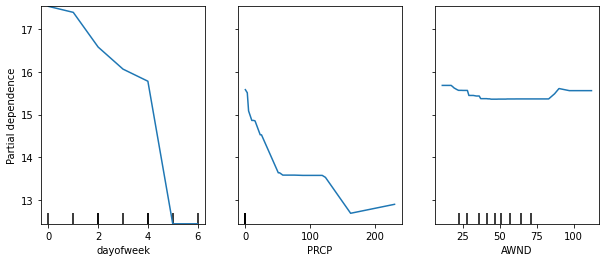

<IPython.core.display.Javascript object>

In [16]:
from sklearn.inspection import plot_partial_dependence

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

plot_partial_dependence(
    pipe_model, X_test, features=["dayofweek", "PRCP", "AWND"], ax=ax
)

Another classical tool that could be used for model interpretability is using the [SHAP library](https://github.com/slundberg/shap). 

It is also important to note that interpetability of ML model, or correlation in general, does not causality. For instance, in the above figure while rain might decrease the volume of "Street and Sidewalk Cleaning" events by making streets cleaner, the most likely explanation is that people stay more indoors on rainy days and therefore fewer notice and report cleanliness issues.

In [17]:
X_test.head()

,dateTime,neighborhood,count,year,month,day,dayofweek,hour,dayofyear,is_holiday,is_holiday_eve,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,2019-05-31 12:00:00,Tenderloin,20,2019,5,31,4,12,151,False,False,57.0,0.0,0.0,140.0,194.0,111.0,112.0
1,2019-05-31 12:00:00,SoMa,42,2019,5,31,4,12,151,False,False,57.0,0.0,0.0,140.0,194.0,111.0,112.0
2,2019-05-31 12:00:00,Ingleside,27,2019,5,31,4,12,151,False,False,57.0,0.0,0.0,140.0,194.0,111.0,112.0
3,2019-05-31 12:00:00,Mission,39,2019,5,31,4,12,151,False,False,57.0,0.0,0.0,140.0,194.0,111.0,112.0
4,2019-05-31 12:00:00,Nob Hill,14,2019,5,31,4,12,151,False,False,57.0,0.0,0.0,140.0,194.0,111.0,112.0


<IPython.core.display.Javascript object>

## 2. Model fairness
To evaluate the fairness of model predictions, we will consider possible biases
in the training data, the cost of prediction errors and the possibility of
feedback loops between model predictions and future collected data.

First we observe that input data does not directly contain sensitive features
such as race, sex, gender etc. Moreover because out target variable
corresponds to an aggregation over a day and a geographical neighborhood,
predictions are not made at the individual level. Nevertheless because
neighborhoods can have different distribution of individuals presenting the above
sensitive features (e.g. there could be higher income neighborhoods), on average the                                                   
training data could present biases and so could model predictions.


It then remains to be seen what impact model predictions (and possible                                           prediction errors) could have in practice.                                                                                             
We can examine the potential impact by event category,                                                                                 
 1. "Street and Sidewalk Cleaning", and "Graffiti" category could impact the                  
    number of cleaning personnel deployed per neighborhood, which appears           
    relatively harmless.                                                                                                               
 2. "Potentially Life-Threatening" and "Non Potentially Life-Threatening" categories                  
    involve medical and other accidents, and require timely response. If a ML                
    model were to be used for these categories, it needs to be very carefully            
    validated.  It is also likely better to over-estimate the required response
    capacity than under-estimate it in this case.                                                                                      
 3. Making predictions for the "Encampments" category is likely problematic, as                 
    they could lead to measures being taken to prevent encampments in the                
    future, negatively impacting affected people. Whether it would be judicious              
    to make predictions for this category would therefore require mode               
    analysis.                                                                                                                          
                                                                                                                                       
Feedback loops, appear when decisions based on predictive models impact the                                       future collected training data.  For instance, imagine our model predicts a                                       large number of "Street and Sidewalk Cleaning" events next week in a                                             neighborhood.  A team is then sent to address this issue in advance, and as a
result fewer such requests are effetely observed.  However this new training                                     data then could lead the model to under-estimate the number of events the
following week. This would then lead to a decrease in the model accuracy, at
least until a steady state is reached.